In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss
import warnings
warnings.filterwarnings('ignore')

In [4]:
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

In [5]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
sample = pd.read_csv('../data/sample_submission.csv')

In [6]:
print("="*50)
print("TRAIN DATASET")
print("="*50)
print(f"Shape: {train.shape}")
print(f"\nColumns:\n{train.columns.tolist()}")
print(f"\nTarget distribution:\n{train['Status'].value_counts()}")

TRAIN DATASET
Shape: (7905, 20)

Columns:
['id', 'N_Days', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage', 'Status']

Target distribution:
Status
C     4965
D     2665
CL     275
Name: count, dtype: int64


In [7]:
print(f"\nData types:\n{train.dtypes}")


Data types:
id                 int64
N_Days             int64
Drug                 str
Age                int64
Sex                  str
Ascites              str
Hepatomegaly         str
Spiders              str
Edema                str
Bilirubin        float64
Cholesterol      float64
Albumin          float64
Copper           float64
Alk_Phos         float64
SGOT             float64
Tryglicerides    float64
Platelets        float64
Prothrombin      float64
Stage            float64
Status               str
dtype: object


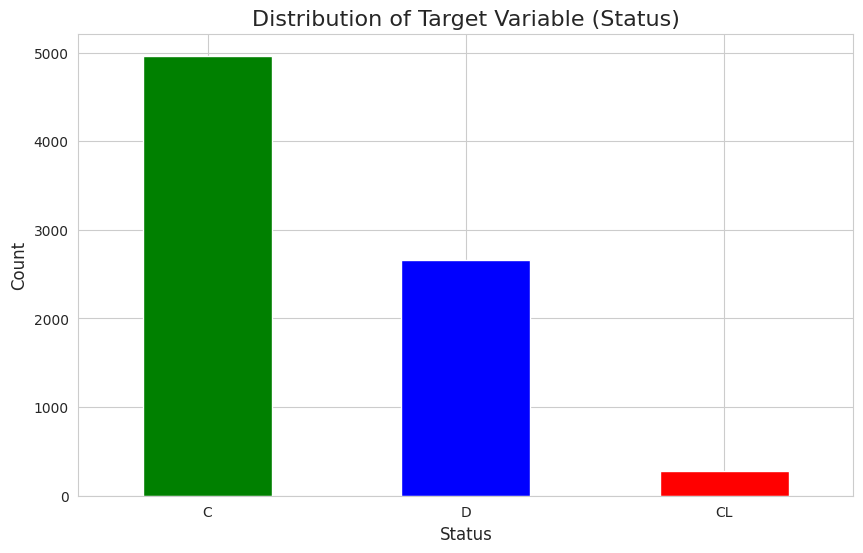

In [8]:
plt.figure(figsize=(10,6))
train['Status'].value_counts().plot(kind='bar', color=['green', 'blue', 'red'])
plt.title('Distribution of Target Variable (Status)', fontsize=16)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.show()

In [9]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('id')
if 'Status' in numeric_cols:
    numeric_cols.remove('Status')

print("Числовые признаки:", numeric_cols)

Числовые признаки: ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']


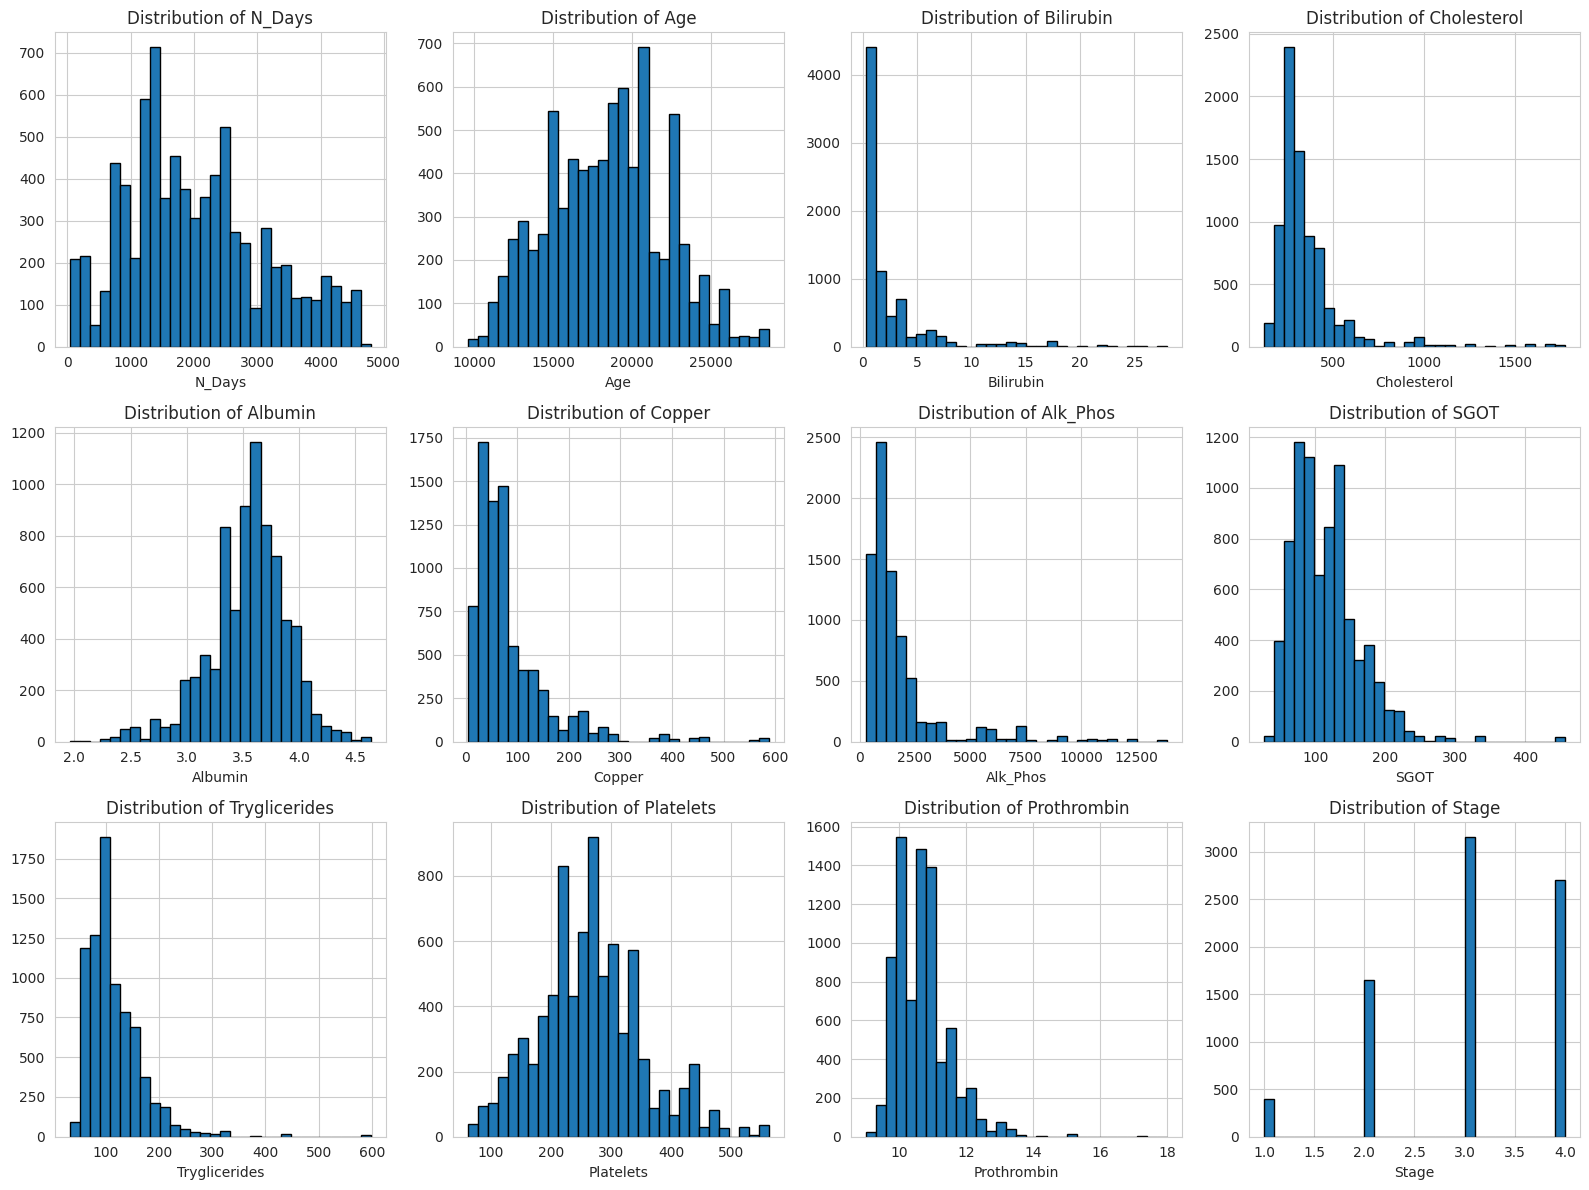

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(numeric_cols[:12]):
    train[col].hist(ax=axes[i], bins=30, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

In [11]:
categorical_cols = ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']
print("Категориальные признаки:", categorical_cols)

Категориальные признаки: ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']


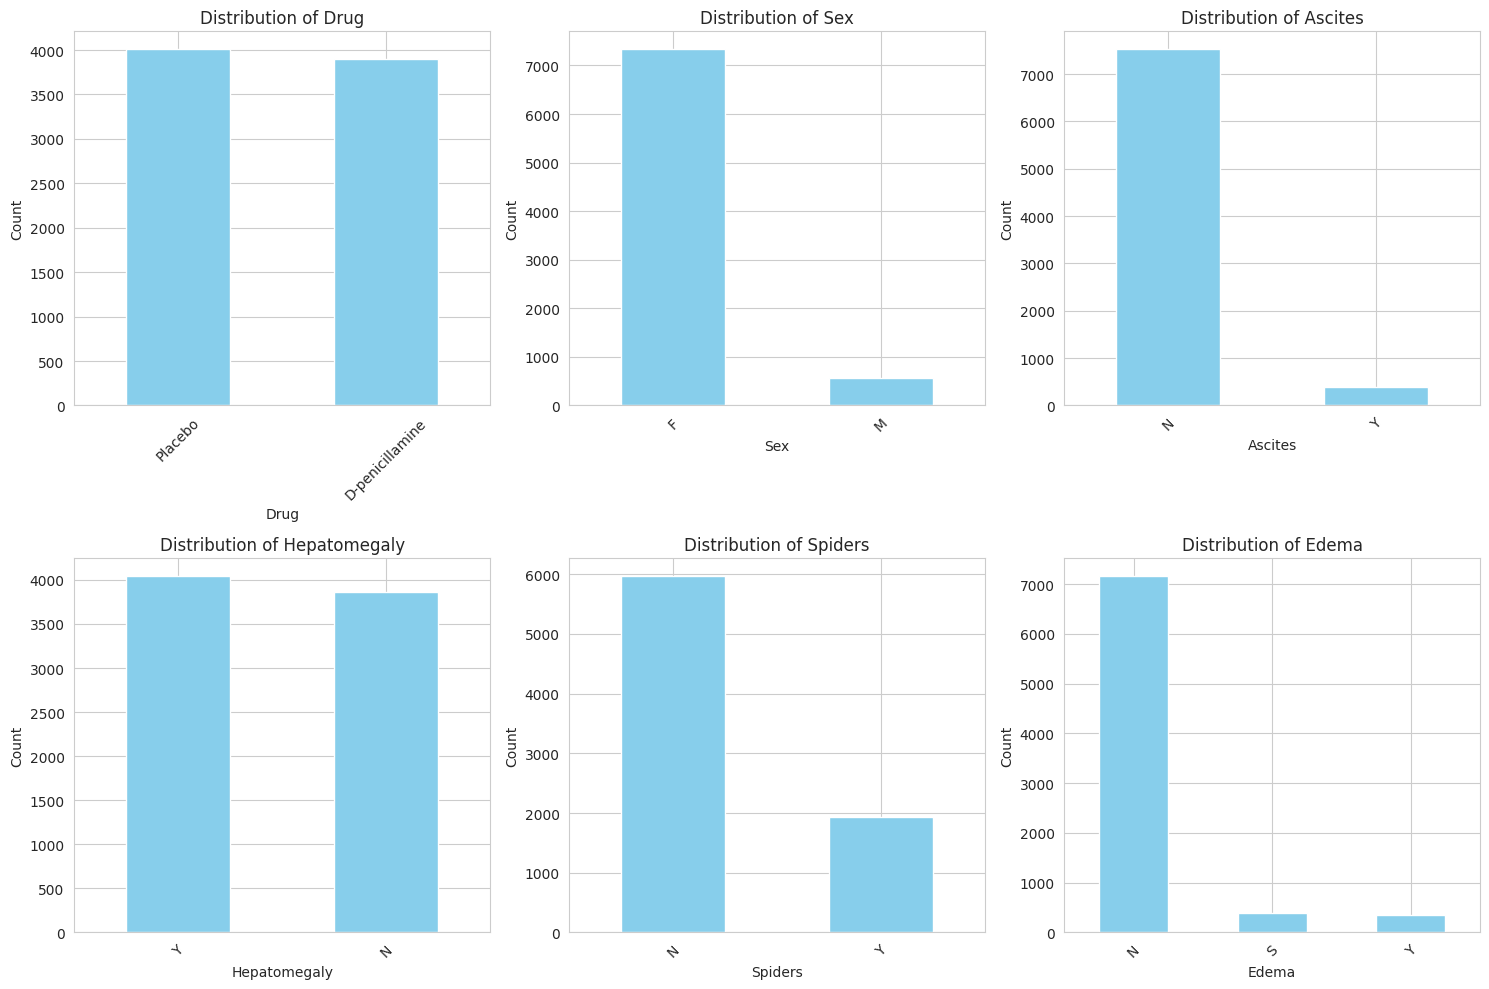

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    train[col].value_counts().plot(kind='bar', ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [13]:
def prepare_data(df, is_train=True):
    data = df.copy()
    
    ids = data['id'] if 'id' in data.columns else None
    if 'id' in data.columns:
        data = data.drop('id', axis=1)
    
    if is_train and 'Status' in data.columns:
        y = data['Status'].copy()
        data = data.drop('Status', axis=1)
    else:
        y = None
    
    categorical_cols = ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']
    
    for col in categorical_cols:
        if col in data.columns:
            le = LabelEncoder()
            data[col] = le.fit_transform(data[col].astype(str))
    
    return data, y, ids

In [14]:
X_train, y_train, _ = prepare_data(train, is_train=True)
X_test, _, test_ids = prepare_data(test, is_train=False)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nКлассы в y_train:", y_train.unique())
print("\nПервые 5 строк X_train:")
X_train.head()

X_train shape: (7905, 18)
X_test shape: (5271, 18)

Классы в y_train: <StringArray>
['D', 'C', 'CL']
Length: 3, dtype: str

Первые 5 строк X_train:


,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,999,0,21532,1,0,0,0,0,2.3,316.0,3.35,172.0,1601.0,179.80,63.0,394.0,9.7,3.0
1,2574,1,19237,0,0,0,0,0,0.9,364.0,3.54,63.0,1440.0,134.85,88.0,361.0,11.0,3.0
2,3428,1,13727,0,0,1,1,2,3.3,299.0,3.55,131.0,1029.0,119.35,50.0,199.0,11.7,4.0
3,2576,1,18460,0,0,0,0,0,0.6,256.0,3.50,58.0,1653.0,71.30,96.0,269.0,10.7,3.0
4,788,1,16658,0,0,1,0,0,1.1,346.0,3.65,63.0,1181.0,125.55,96.0,298.0,10.6,4.0


In [15]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print("Размер обучающей выборки:", len(X_tr))
print("Размер валидационной выборки:", len(X_val))

Размер обучающей выборки: 6324
Размер валидационной выборки: 1581


In [17]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_tr, y_tr)
lr_pred = lr.predict_proba(X_val)
lr_loss = log_loss(y_val, lr_pred)
print(f"Logistic Regression Log Loss: {lr_loss:.4f}")

Logistic Regression Log Loss: 0.6125


In [18]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_tr, y_tr)
rf_pred = rf.predict_proba(X_val)
rf_loss = log_loss(y_val, rf_pred)
print(f"Random Forest Log Loss: {rf_loss:.4f}")

Random Forest Log Loss: 0.5716
